# Cracking Onset: `perform_check` vs `M_cr`

This notebook sweeps load cases (`M`, `N`) and compares:
- **Crack onset moment** inferred from `CrackingCheck.perform_check(...)`
- **Cracking moment helper** `CrackingCheck.find_cracking_moment(...)`

It repeats the comparison for multiple section heights so the size-effect term in `f_ctm,fl` is exercised.

In [1]:
import warnings
from dataclasses import dataclass
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from section_design_checks.reinforced_concrete.geometry import (
    create_rectangular_section,
    create_linear_rebar_layer,
)
from section_design_checks.reinforced_concrete.materials import ConcreteMaterial, Rebar
from section_design_checks.reinforced_concrete.code_checks.ec2_2004.cracking_check import CrackingCheck

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
@dataclass
class CrackState:
    is_cracked: bool
    details: Dict
    status: str


def make_section(height: float, width: float = 300.0, cover: float = 35.0) -> object:
    """Rectangular section with symmetric top/bottom reinforcement."""
    section = create_rectangular_section(width=width, height=height)

    dia = 20.0
    bar = Rebar(diameter=dia, grade="B500B")
    y_bot = cover + dia / 2.0
    y_top = height - y_bot
    x_start = cover + dia / 2.0
    x_end = width - (cover + dia / 2.0)

    bottom = create_linear_rebar_layer(
        rebar=bar,
        n_bars=3,
        start_point=(x_start, y_bot),
        end_point=(x_end, y_bot),
        layer_name="bottom",
    )
    top = create_linear_rebar_layer(
        rebar=bar,
        n_bars=3,
        start_point=(x_start, y_top),
        end_point=(x_end, y_top),
        layer_name="top",
    )

    section.add_rebar_group(bottom)
    section.add_rebar_group(top)
    return section


def make_check(section: object) -> CrackingCheck:
    concrete = ConcreteMaterial(grade="C30/37")
    return CrackingCheck(
        section=section,
        concrete=concrete,
        creep_coefficient=0.0,
        check_k1_stress=False,
        check_k2_stress=False,
        check_k3_stress=False,
        check_yielding=False,
        check_k4_stress=False,
        apply_nonlinear_creep=False,
    )


def eval_state(check: CrackingCheck, M_Ed: float, N_Ed: float) -> CrackState:
    result = check.perform_check(
        M_Ed=float(M_Ed),
        N_Ed=float(N_Ed),
        suppress_warnings=True,
    )
    details = result.details or {}

    # On solver failure branches, "is_cracked" may be absent.
    # Treat as cracked for bracketing purposes.
    is_cracked = bool(details.get("is_cracked", True))
    return CrackState(
        is_cracked=is_cracked,
        details=details,
        status=str(result.status),
    )


def find_crack_onset_moment(
    check: CrackingCheck,
    N_Ed: float,
    sign: int = 1,
    max_m: float = 1500.0,
    tol: float = 5e-2,
    max_iter: int = 35,
) -> Tuple[float, CrackState]:
    """
    Find |M| where perform_check transitions to cracked for fixed N and moment sign.
    Returns (M_onset_signed, state_at_onset).
    """
    sign = 1 if sign >= 0 else -1

    state_zero = eval_state(check, 0.0, N_Ed)
    if state_zero.is_cracked:
        return 0.0, state_zero

    m_guess = abs(float(check.find_cracking_moment(N_Ed=N_Ed)))
    low = 0.0
    high = max(20.0, 1.25 * m_guess)
    state_high = eval_state(check, sign * high, N_Ed)

    expand_count = 0
    while (not state_high.is_cracked) and (high < max_m) and (expand_count < 30):
        low = high
        high = min(max_m, 1.6 * high + 5.0)
        state_high = eval_state(check, sign * high, N_Ed)
        expand_count += 1

    if not state_high.is_cracked:
        return np.nan, state_high

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        state_mid = eval_state(check, sign * mid, N_Ed)

        if state_mid.is_cracked:
            high = mid
            state_high = state_mid
        else:
            low = mid

        if (high - low) <= tol:
            break

    return sign * high, state_high

In [3]:
# Parameter sweep
section_heights = [300.0, 500.0, 900.0]   # mm
axial_forces = [-100.0, 0.0, 200.0, 500.0]  # kN (compression +)
moment_signs = [1, -1]

rows = []

for h in section_heights:
    section = make_section(height=h, width=300.0, cover=35.0)
    check = make_check(section)

    for N in axial_forces:
        m_cr_calc = float(check.find_cracking_moment(N_Ed=N, use_f_ctm_fl=False))
        state_zero = eval_state(check, M_Ed=0.0, N_Ed=N)
        m_cr_reported = state_zero.details.get("M_cr", np.nan)

        for sgn in moment_signs:
            m_onset, state_onset = find_crack_onset_moment(
                check,
                N_Ed=N,
                sign=sgn,
                max_m=1500.0,
                tol=5e-2,
            )

            rows.append(
                {
                    "height_mm": h,
                    "N_kN": N,
                    "moment_sign": "+" if sgn > 0 else "-",
                    "M_onset_kNm": m_onset,
                    "M_cr_calc_kNm": m_cr_calc,
                    "M_cr_reported_kNm": float(m_cr_reported) if m_cr_reported is not None else np.nan,
                    "status_at_onset": state_onset.status,
                    "is_cracked_at_onset": state_onset.is_cracked,
                }
            )

df = pd.DataFrame(rows)
df["delta_vs_calc_kNm"] = abs(df["M_onset_kNm"]) - abs(df["M_cr_calc_kNm"])
df["delta_vs_reported_kNm"] = abs(df["M_onset_kNm"]) - abs(df["M_cr_reported_kNm"])
df["ratio_vs_calc"] = abs(df["M_onset_kNm"]) / abs(df["M_cr_calc_kNm"]).replace(0.0, np.nan)

summary = (
    df.groupby(["height_mm", "N_kN"], as_index=False)[
        [
            "M_onset_kNm",
            "M_cr_calc_kNm",
            "M_cr_reported_kNm",
            "delta_vs_calc_kNm",
            "ratio_vs_calc",
        ]
    ]
    .mean()
)

print("Raw results (first 12 rows):")
display(df.head(12))
print("\nAveraged over moment sign (by height, N):")
display(summary)

Raw results (first 12 rows):


,height_mm,N_kN,moment_sign,M_onset_kNm,M_cr_calc_kNm,M_cr_reported_kNm,status_at_onset,is_cracked_at_onset,delta_vs_calc_kNm,delta_vs_reported_kNm,ratio_vs_calc
0,300.0,-100.0,+,11.210938,9.850559,9.850559,CheckStatus.PASS,True,1.360379,1.360379,1.138102
1,300.0,-100.0,-,-11.210938,9.850559,9.850559,CheckStatus.PASS,True,1.360379,1.360379,1.138102
2,300.0,0.0,+,16.601562,15.076977,15.076977,CheckStatus.PASS,True,1.524586,1.524586,1.101120
3,300.0,0.0,-,-16.601562,15.076977,15.076977,CheckStatus.PASS,True,1.524586,1.524586,1.101120
4,300.0,200.0,+,27.393439,25.529813,25.529813,CheckStatus.PASS,True,1.863626,1.863626,1.072998
5,300.0,200.0,-,-27.393439,25.529813,25.529813,CheckStatus.PASS,True,1.863626,1.863626,1.072998
6,300.0,500.0,+,43.613600,41.209067,41.209067,CheckStatus.PASS,True,2.404533,2.404533,1.058350
7,300.0,500.0,-,-43.613600,41.209067,41.209067,CheckStatus.PASS,True,2.404533,2.404533,1.058350
8,500.0,-100.0,+,34.119358,53.391744,53.391744,CheckStatus.PASS,True,-19.272386,-19.272386,0.639038
9,500.0,-100.0,-,-34.119358,53.391744,53.391744,CheckStatus.PASS,True,-19.272386,-19.272386,0.639038



Averaged over moment sign (by height, N):


,height_mm,N_kN,M_onset_kNm,M_cr_calc_kNm,M_cr_reported_kNm,delta_vs_calc_kNm,ratio_vs_calc
0,300.0,-100.0,0.0,9.850559,9.850559,1.360379,1.138102
1,300.0,0.0,0.0,15.076977,15.076977,1.524586,1.101120
2,300.0,200.0,0.0,25.529813,25.529813,1.863626,1.072998
3,300.0,500.0,0.0,41.209067,41.209067,2.404533,1.058350
4,500.0,-100.0,0.0,53.391744,53.391744,-19.272386,0.639038
5,500.0,0.0,0.0,68.130081,68.130081,-24.841864,0.635376
6,500.0,200.0,0.0,97.606755,97.606755,-36.066363,0.630493
7,500.0,500.0,0.0,141.821766,141.821766,-52.836918,0.627441
8,900.0,-100.0,0.0,335.105258,335.105258,-218.624274,0.347595
9,900.0,0.0,0.0,382.313784,382.313784,-249.569183,0.347214


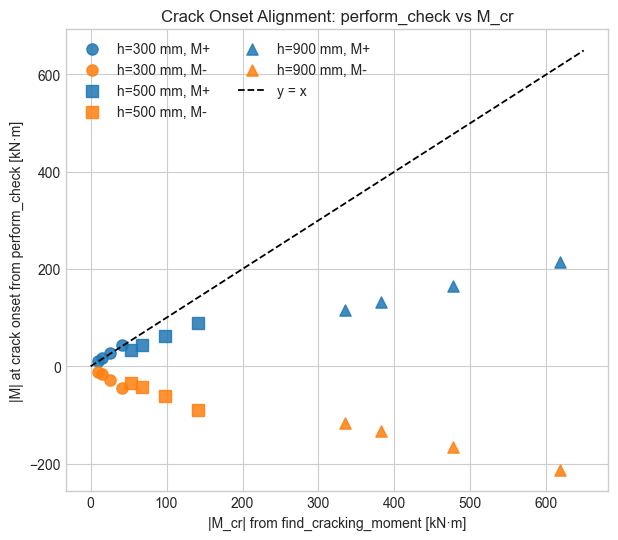

In [4]:
# Plot 1: onset from perform_check vs M_cr (calculated)
valid = df[np.isfinite(df["M_onset_kNm"])].copy()

fig, ax = plt.subplots(figsize=(7, 6))
markers = {300.0: "o", 500.0: "s", 900.0: "^"}
colors = {"+": "tab:blue", "-": "tab:orange"}

for (h, sgn), grp in valid.groupby(["height_mm", "moment_sign"]):
    ax.scatter(
        grp["M_cr_calc_kNm"],
        grp["M_onset_kNm"],
        marker=markers[h],
        color=colors[sgn],
        s=65,
        alpha=0.85,
        label=f"h={int(h)} mm, M{sgn}",
    )

xy_max = np.nanmax(
    [valid["M_cr_calc_kNm"].max(), valid["M_onset_kNm"].max()]
)
line = np.linspace(0.0, xy_max * 1.05, 100)
ax.plot(line, line, "k--", linewidth=1.3, label="y = x")

ax.set_xlabel("|M_cr| from find_cracking_moment [kN·m]")
ax.set_ylabel("|M| at crack onset from perform_check [kN·m]")
ax.set_title("Crack Onset Alignment: perform_check vs M_cr")
ax.legend(loc="best", ncol=2)
plt.show()

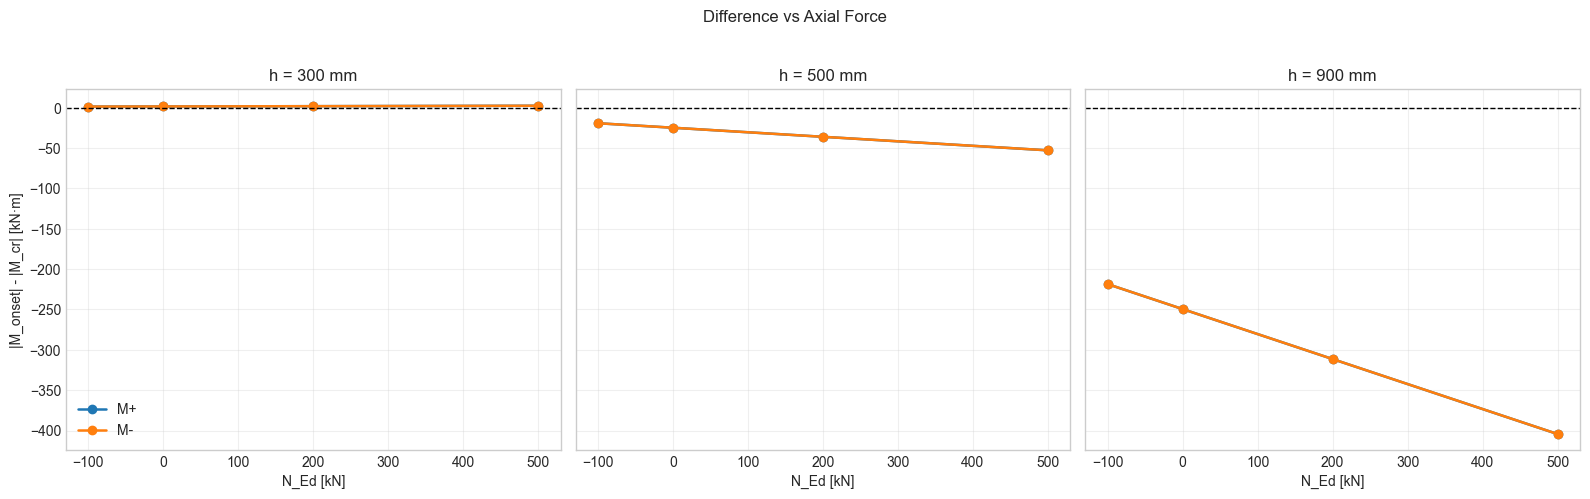

In [5]:
# Plot 2: difference (onset - M_cr) vs axial force for each height
fig, axes = plt.subplots(1, len(section_heights), figsize=(16, 4.8), sharey=True)
if len(section_heights) == 1:
    axes = [axes]

for ax, h in zip(axes, section_heights):
    sub = valid[valid["height_mm"] == h]
    for sgn in ["+", "-"]:
        g = sub[sub["moment_sign"] == sgn].sort_values("N_kN")
        ax.plot(
            g["N_kN"],
            g["delta_vs_calc_kNm"],
            marker="o",
            linewidth=1.8,
            label=f"M{sgn}",
        )

    ax.axhline(0.0, color="k", linestyle="--", linewidth=1.0)
    ax.set_title(f"h = {int(h)} mm")
    ax.set_xlabel("N_Ed [kN]")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("|M_onset| - |M_cr| [kN·m]")
axes[0].legend(loc="best")
fig.suptitle("Difference vs Axial Force", y=1.03)
plt.tight_layout()
plt.show()

In [6]:
# Quick numerical diagnostics
diag = (
    summary.assign(abs_delta=lambda d: d["delta_vs_calc_kNm"].abs())
    .groupby("height_mm", as_index=False)[["abs_delta", "ratio_vs_calc"]]
    .agg(["mean", "max"])
)
diag

height_mm   abs_delta             ratio_vs_calc          
                   mean         max          mean       max
0     300.0    1.788281    2.404533      1.092642  1.138102
1     500.0   33.254383   52.836918      0.633087  0.639038
2     900.0  295.991609  404.315042      0.346909  0.347595